In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [3]:
skolky_body = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")
obce_polygony = gpd.read_file("geometrie/obce_slbd.geojson").to_crs(5514)
obce_polygony = obce_polygony[["geometry","celkem", "Kód_obce"]]

In [8]:
skolky_body["monthly_fe"].notna().sum()

np.int64(1812)

In [188]:
pocet_skolek = gpd.sjoin(skolky_body, obce_polygony, how="inner", predicate="within")
obce_polygony["count"] = pocet_skolek.groupby("index_right").size()
#obce_polygony["count"] = obce_polygony["count"].fillna(0)



In [189]:
#obce_skolky= gpd.sjoin(skolky_body,obce_polygony)
obce_skolky = gpd.sjoin(obce_polygony,skolky_body)

In [190]:
obce_skolky


,geometry,celkem,Kód_obce,count,RED_IZO,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe
0,"POLYGON Z ((-516000.187 -1165924.458 0, -51592...",1817.0,500011,1.0,691000832.0,2.0,Zlínský kraj,Zlín,7213.0,http://www.zszelechovice.cz/,Základní škola a Mateřská škola Želechovice na...,500.0
2,"POLYGON Z ((-488886.802 -1121478.332 0, -48885...",1699.0,500046,1.0,691002886.0,2.0,Moravskoslezský kraj,Nový Jičín,8115.0,www.zsamslibhost.cz,"Základní škola a Mateřská škola, Libhošť 90, p...",NaN
3,"POLYGON Z ((-491809.633 -1136525.891 0, -49179...",2020.0,500062,1.0,691005184.0,2.0,Zlínský kraj,Valašské Meziříčí,7210.0,http://mskrhova.blog.cz,"Mateřská škola Krhová, příspěvková organizace",NaN
4,"POLYGON Z ((-497756.406 -1138700.653 0, -49772...",1716.0,500071,1.0,691005176.0,2.0,Zlínský kraj,Valašské Meziříčí,7210.0,www.zs-policna.cz,"Základní škola a Mateřská škola Poličná 276, p...",NaN
9,"POLYGON Z ((-525067.495 -1103833.211 0, -52508...",529.0,500160,1.0,691009660.0,2.0,Olomoucký kraj,Šternberk,7110.0,www.zsmestolibava.cz,"Základní škola a Mateřská škola Město Libavá, ...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
6253,"POLYGON Z ((-498402.054 -1116037.041 0, -49831...",2541.0,599930,1.0,600138208.0,2.0,Moravskoslezský kraj,Nový Jičín,8115.0,www.skolasuchdol.cz,Základní škola a mateřská škola Suchdol nad Od...,500.0
6254,"POLYGON Z ((-486307.526 -1125914.677 0, -48628...",3341.0,599948,1.0,600138283.0,2.0,Moravskoslezský kraj,Kopřivnice,8112.0,http://www.zsstramberk.cz,Základní škola a Mateřská škola Štramberk,500.0
6255,"POLYGON Z ((-477251.967 -1127563.093 0, -47724...",1813.0,599956,1.0,600138089.0,2.0,Moravskoslezský kraj,Frenštát pod Radhoštěm,8105.0,zsticha.cz,"Základní škola a mateřská škola Tichá, příspěv...",NaN
6256,"POLYGON Z ((-491041.565 -1103015.089 0, -49103...",962.0,599964,1.0,600138372.0,2.0,Moravskoslezský kraj,Bílovec,8101.0,www.zsamstisek.cz,"Základní škola a Mateřská škola Tísek, příspěv...",NaN


In [191]:
bins = [0, 200, 500, 1000, 2000, 5000, 10_000,50_000,100_000,float('inf')]
labels = [1, 2, 3, 4, 5,6,7,8,9]

obce_skolky["size_category"] = pd.cut(
    obce_skolky["celkem"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)


In [192]:
std_price = obce_skolky.groupby('Kód_obce').agg({
    'monthly_fe': 'std',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce','monthly_fe']}
})


In [193]:
avg_price = obce_skolky.groupby('Kód_obce').agg({
    'monthly_fe': 'mean',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce','monthly_fe']}
})


In [194]:
avg = avg_price.pivot_table(
    values="monthly_fe",
    index="Kraj",
    columns="size_category",
    aggfunc="mean"
).round()
avg


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97599/2352476119.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  avg = avg_price.pivot_table(


size_category,1,2,3,4,5,6,7,8,9
Kraj,,,,,,,,,
Hlavní město Praha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1192.0
Jihomoravský kraj,NaN,369.0,394.0,449.0,481.0,620.0,644.0,NaN,849.0
Jihočeský kraj,NaN,356.0,367.0,356.0,404.0,479.0,426.0,420.0,NaN
Karlovarský kraj,NaN,267.0,450.0,458.0,420.0,467.0,599.0,NaN,NaN
Kraj Vysočina,NaN,258.0,316.0,386.0,394.0,560.0,600.0,700.0,NaN
Královéhradecký kraj,450.0,388.0,420.0,418.0,431.0,457.0,675.0,575.0,NaN
Liberecký kraj,NaN,467.0,450.0,531.0,390.0,489.0,733.0,NaN,862.0
Moravskoslezský kraj,NaN,274.0,371.0,432.0,555.0,561.0,537.0,642.0,747.0
Olomoucký kraj,0.0,238.0,398.0,341.0,453.0,550.0,671.0,NaN,625.0


In [195]:
avg.mean(axis=0).round()

size_category
1    256.0
2    369.0
3    409.0
4    448.0
5    477.0
6    539.0
7    637.0
8    650.0
9    829.0
dtype: float64

In [196]:
std = std_price.pivot_table(
    values="monthly_fe",
    index="Kraj",
    columns="size_category",
    aggfunc="mean"
).round()
std


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97599/3983303539.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  std = std_price.pivot_table(


size_category,4,5,6,7,8,9
Kraj,,,,,,
Hlavní město Praha,NaN,NaN,NaN,NaN,NaN,234.0
Jihomoravský kraj,NaN,NaN,0.0,17.0,NaN,156.0
Jihočeský kraj,NaN,NaN,0.0,18.0,0.0,NaN
Karlovarský kraj,NaN,71.0,115.0,19.0,NaN,NaN
Kraj Vysočina,NaN,NaN,NaN,0.0,141.0,NaN
Královéhradecký kraj,NaN,212.0,0.0,53.0,87.0,NaN
Liberecký kraj,NaN,0.0,131.0,25.0,NaN,56.0
Moravskoslezský kraj,NaN,0.0,0.0,46.0,56.0,215.0
Olomoucký kraj,NaN,NaN,0.0,55.0,NaN,61.0


In [197]:
std.mean(axis=0).round()

size_category
4    177.0
5     57.0
6     26.0
7     25.0
8     58.0
9    120.0
dtype: float64

In [205]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]

In [207]:
obce_skolky

,geometry,celkem,Kód_obce,count,RED_IZO,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,size_category
0,"POLYGON Z ((-516000.187 -1165924.458 0, -51592...",1817.0,500011,1.0,691000832.0,2.0,Zlínský kraj,Zlín,7213.0,http://www.zszelechovice.cz/,Základní škola a Mateřská škola Želechovice na...,500.0,4
2,"POLYGON Z ((-488886.802 -1121478.332 0, -48885...",1699.0,500046,1.0,691002886.0,2.0,Moravskoslezský kraj,Nový Jičín,8115.0,www.zsamslibhost.cz,"Základní škola a Mateřská škola, Libhošť 90, p...",NaN,4
3,"POLYGON Z ((-491809.633 -1136525.891 0, -49179...",2020.0,500062,1.0,691005184.0,2.0,Zlínský kraj,Valašské Meziříčí,7210.0,http://mskrhova.blog.cz,"Mateřská škola Krhová, příspěvková organizace",NaN,5
4,"POLYGON Z ((-497756.406 -1138700.653 0, -49772...",1716.0,500071,1.0,691005176.0,2.0,Zlínský kraj,Valašské Meziříčí,7210.0,www.zs-policna.cz,"Základní škola a Mateřská škola Poličná 276, p...",NaN,4
9,"POLYGON Z ((-525067.495 -1103833.211 0, -52508...",529.0,500160,1.0,691009660.0,2.0,Olomoucký kraj,Šternberk,7110.0,www.zsmestolibava.cz,"Základní škola a Mateřská škola Město Libavá, ...",NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6253,"POLYGON Z ((-498402.054 -1116037.041 0, -49831...",2541.0,599930,1.0,600138208.0,2.0,Moravskoslezský kraj,Nový Jičín,8115.0,www.skolasuchdol.cz,Základní škola a mateřská škola Suchdol nad Od...,500.0,5
6254,"POLYGON Z ((-486307.526 -1125914.677 0, -48628...",3341.0,599948,1.0,600138283.0,2.0,Moravskoslezský kraj,Kopřivnice,8112.0,http://www.zsstramberk.cz,Základní škola a Mateřská škola Štramberk,500.0,5
6255,"POLYGON Z ((-477251.967 -1127563.093 0, -47724...",1813.0,599956,1.0,600138089.0,2.0,Moravskoslezský kraj,Frenštát pod Radhoštěm,8105.0,zsticha.cz,"Základní škola a mateřská škola Tichá, příspěv...",NaN,4
6256,"POLYGON Z ((-491041.565 -1103015.089 0, -49103...",962.0,599964,1.0,600138372.0,2.0,Moravskoslezský kraj,Bílovec,8101.0,www.zsamstisek.cz,"Základní škola a Mateřská škola Tísek, příspěv...",NaN,3


In [206]:
size_counts_total = obce_skolky.groupby("size_category").size()
size_counts = fee.groupby('size_category').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('size_category')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('size_category')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('size_category')['monthly_fe'].std()

table.round()

/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97599/2672294070.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts_total = obce_skolky.groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97599/2672294070.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts = fee.groupby('size_category').size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97599/2672294070.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior

,total_count,count,percentage,average_fee,median_fee,std_fee
size_category,,,,,,
1,40,7,18.0,293.0,400.0,210.0
2,679,175,26.0,391.0,350.0,217.0
3,1192,353,30.0,438.0,400.0,225.0
4,771,345,45.0,485.0,400.0,247.0
5,473,202,43.0,526.0,500.0,242.0
6,263,109,41.0,546.0,500.0,166.0
7,563,240,43.0,664.0,600.0,221.0
8,203,78,38.0,662.0,650.0,154.0
9,604,303,50.0,1010.0,1000.0,287.0


In [216]:
tables_by_kraj = {}

for kraj, df_kraj in obce_skolky.groupby("Název_ORP"):

    size_counts_total = df_kraj.groupby("size_category").size()
    size_counts = df_kraj[df_kraj["monthly_fe"].notna()].groupby("size_category").size()

    table = pd.DataFrame({
        "total_count": size_counts_total,
        "count": size_counts
    })

    table["percentage"] = table["count"] / table["total_count"] * 100
    table["average_fee"] = df_kraj.groupby("size_category")["monthly_fe"].mean()
    table["median_fee"] = df_kraj.groupby("size_category")["monthly_fe"].median()
    table["std_fee"] = df_kraj.groupby("size_category")["monthly_fe"].std()

    tables_by_kraj[kraj] = table.round()


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97599/1157519574.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts_total = df_kraj.groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97599/1157519574.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts = df_kraj[df_kraj["monthly_fe"].notna()].groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97599/1157519574.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

In [217]:
tables_by_kraj["Tachov"]


,total_count,count,percentage,average_fee,median_fee,std_fee
size_category,,,,,,
1,0,0,NaN,NaN,NaN,NaN
2,4,2,50.0,450.0,450.0,212.0
3,4,1,25.0,350.0,350.0,NaN
4,4,3,75.0,333.0,400.0,115.0
5,1,0,0.0,NaN,NaN,NaN
6,1,0,0.0,NaN,NaN,NaN
7,5,5,100.0,1000.0,1000.0,0.0
8,0,0,NaN,NaN,NaN,NaN
9,0,0,NaN,NaN,NaN,NaN


In [201]:
obce = obce_skolky.merge(table, left_on ="size_category", right_index=True)

In [202]:
obce = obce_polygony.merge(
    obce.drop(columns="geometry"),
    on="Kód_obce",
    how="left"
)


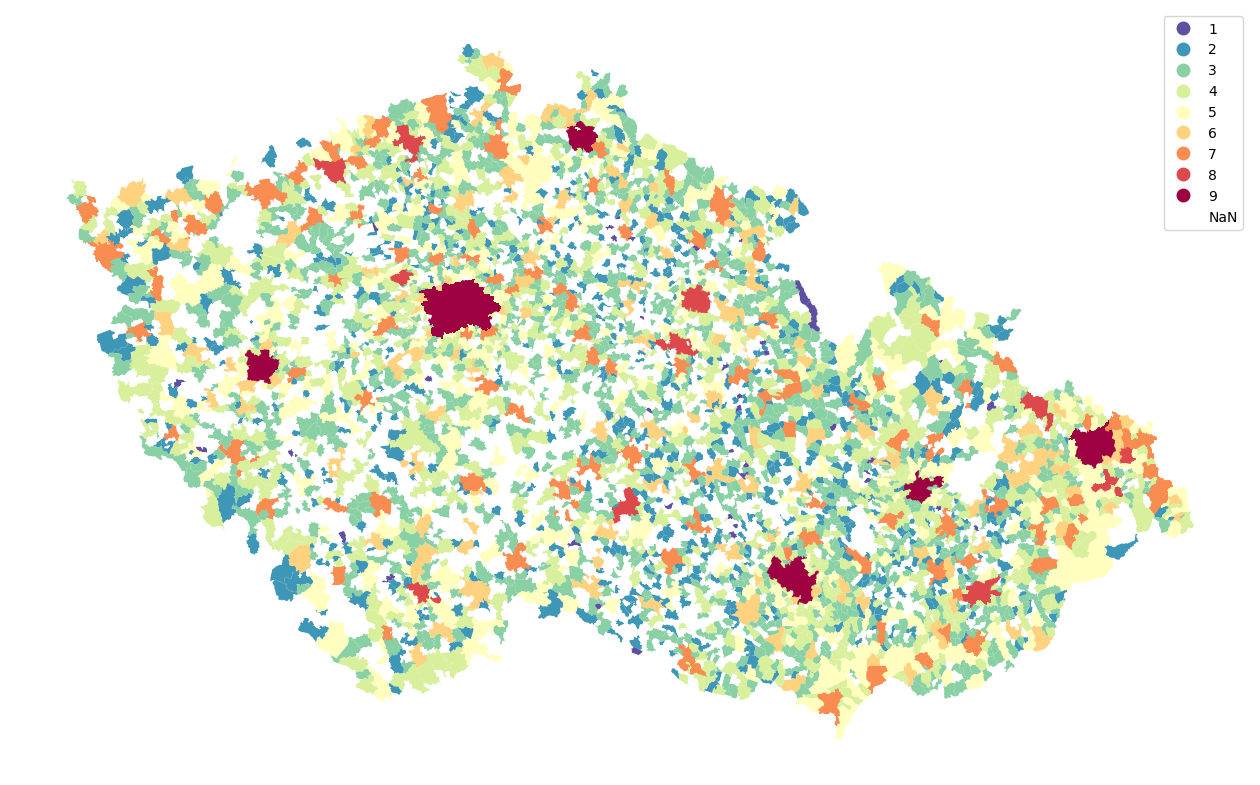

In [204]:
obce.plot("size_category", figsize=(16,10),legend=True,cmap="Spectral_r",missing_kwds={"color": "white"},
).set_axis_off()

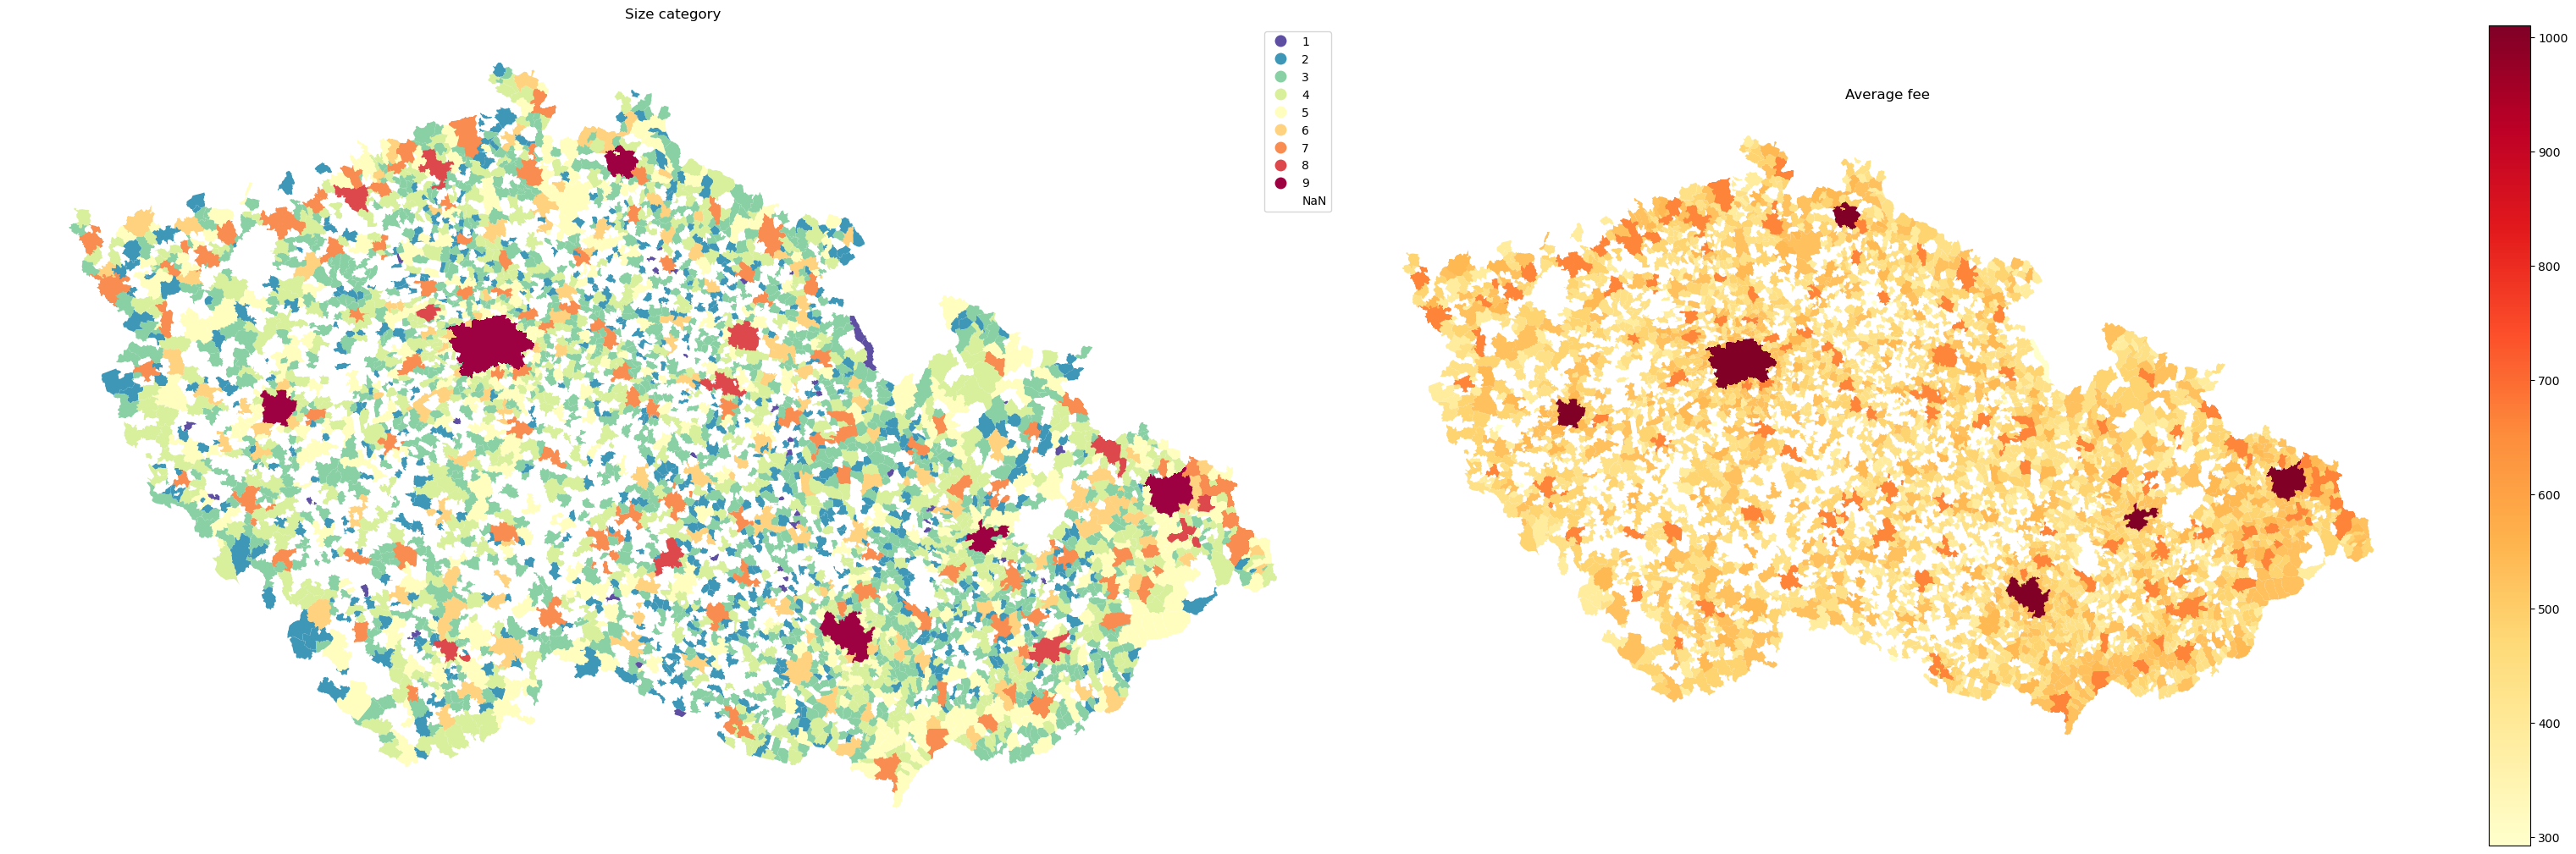

In [184]:
fig, axes = plt.subplots(1, 2, figsize=(32, 10))

obce.plot(
    column="size_category",
    ax=axes[0],
    legend=True,
    cmap="Spectral_r",
    missing_kwds={"color": "white"}
)
axes[0].set_title("Size category")
axes[0].set_axis_off()

obce.plot(
    column="average_fee",
    ax=axes[1],
    legend=True,
    cmap="YlOrRd",
    missing_kwds={"color": "white"}
)
axes[1].set_title("Average fee")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


In [185]:
orp_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/ORP.geojson")
orp_polygony["naz_orp_p"] = orp_polygony["naz_orp_p"].replace({"Praha": "Hlavní město Praha"})